In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/spam_mail.csv")
df.rename(columns = {"Category":"category","Masseges":"messages"},inplace=True)
df.isna().sum()


category    0
messages    0
dtype: int64

In [14]:
x = df['messages']
y = df['category']

y = y.map({"ham":0,"spam":1})

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state = 42,
    test_size = 0.2,
    stratify = y
)

y_train_val = y_train.values
y_test_val = y_test.values

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = 2 # spam/ham
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
train_encoding = tokenizer(
    list(x_train),
    truncation = True,
    padding = True,
    max_length = 64 # padding length
)

test_encoding = tokenizer(
    list(x_test),
    truncation = True,
    padding = True,
    max_length = 64
)

In [7]:
class spamDataset(torch.utils.data.Dataset):
    def __init__(self,encodings,labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key,val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

In [15]:
train_dataset = spamDataset(train_encoding,y_train_val)
test_dataset = spamDataset(test_encoding,y_test_val)

In [16]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir = "../results",
    num_train_epochs = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    logging_steps = 10,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [17]:
trainer.train()

/opt/anaconda3/envs/cnn_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.523931
20,0.227317
30,0.085275
40,0.162825
50,0.074066
60,0.136015
70,0.041848
80,0.040849
90,0.039374
100,0.070561


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/envs/cnn_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=837, training_loss=0.03658157318503359, metrics={'train_runtime': 510.5065, 'train_samples_per_second': 26.192, 'train_steps_per_second': 1.64, 'total_flos': 439757240152320.0, 'train_loss': 0.03658157318503359, 'epoch': 3.0})

In [19]:
trainer.evaluate()

/opt/anaconda3/envs/cnn_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step
0.000368,0.041806,837


{'eval_loss': 0.0418064184486866}

In [24]:
bert_pred = trainer.predict(test_dataset)

In [30]:
logits = bert_pred.predictions
y_true = bert_pred.label_ids

Converting logits to predicted classes
-

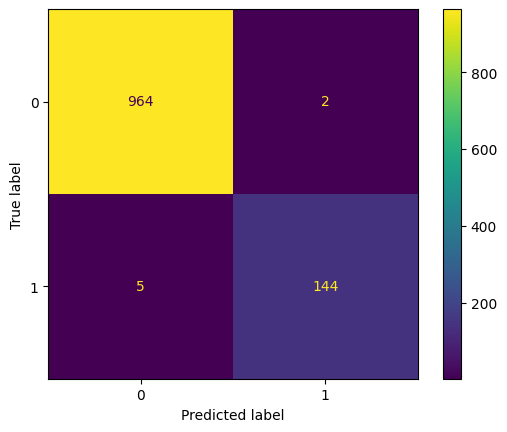

In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(logits, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       0.99      0.97      0.98       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.99      1115
weighted avg       0.99      0.99      0.99      1115



In [41]:
mis_indx = np.where(y_true != y_pred)
mis_indx[0][0]

np.int64(235)

In [45]:
for i in mis_indx[0]:
    print(f"Message: {x_test.iloc[i]}\nPredicted: {y_pred[i]}\nTrue: {y_test.iloc[i]}\n")

Message: Latest News! Police station toilet stolen, cops have nothing to go on!
Predicted: 0
True: 1

Message: MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*
Predicted: 1
True: 0

Message: Bought one ringtone and now getting texts costing 3 pound offering more tones etc
Predicted: 0
True: 1

Message: 645
Predicted: 1
True: 0

Message: For sale - arsenal dartboard. Good condition but no doubles or trebles!
Predicted: 0
True: 1

Message: ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are bringing in a real breath of sunshine.
Predicted: 0
True: 1

Message: RCT' THNQ Adrian for U text. Rgds Vatian
Predicted: 0
True: 1

